In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Import data, read data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Question 1: column with missing values

In [4]:
variables = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [5]:
df[variables].isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Question 2: Median of horsepower

In [6]:
df['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

Median is 254.0

# Q3: Mean or Zero?

Try filling in the missing or nan values with 0, and with the mean. Compute mean with training set only. Check which ones gives better results (RMSE) on the validation dataset

In [7]:
# Check which variables are numbers and which are strings
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

We need to turn the desired variables into numerical (float64).

In [13]:
df[variables] = df[variables].astype(float)

In [22]:
Xvariables = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def prepare_X_withZero(df):
    dfX = df.copy()

    df_num = dfX[Xvariables]
    df_num['horsepower'] = df_num['horsepower'].fillna(0)
    X = df_num.values
    return X

def prepare_X_withMean(df):
    df = df.copy()

    df_num = df[Xvariables]
    df_num['horsepower'] = df_num['horsepower'].fillna(df_num['horsepower'].mean())
    X = df_num.values
    return X

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

Train, validation and test datasets

In [18]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - (n_val + n_test)

np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
len(df_train), len(df_val), len(df_test)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_train

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

Check zero-mean first

In [26]:
X_train = prepare_X_withZero(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X_withZero(df_val)
y_pred_zeros = w0 + X_val.dot(w)
print(f" The RMSE when we fill in the missing entries with zeros is: {round(rmse(y_val, y_pred_zeros),3)}")

X_train = prepare_X_withMean(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X_withMean(df_val)
y_pred_mean = w0 + X_val.dot(w)
print(f" The RMSE when we fill in the missing entries with the mean is: {round(rmse(y_val, y_pred_mean), 3)}")

 The RMSE when we fill in the missing entries with zeros is: 2.163
 The RMSE when we fill in the missing entries with the mean is: 2.159


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

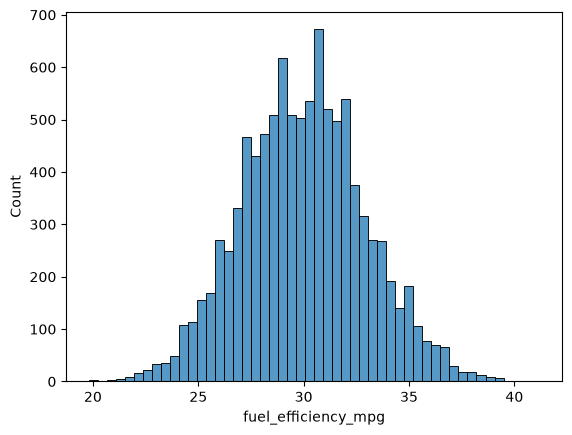

In [11]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)

# Q4: Regularization

Fill the nans with zero and regularize, trying from the list [0, 0.01, 0.1, 1, 5, 10, 100]. Which one gives the best RMSE?

In [44]:
reg_parameter = np.array([0, 0.01, 0.1, 1, 5, 10, 100])
rmse_errors = []

X_train = prepare_X_withZero(df_train)

for reg in reg_parameter:
    w0, w = train_linear_regression_reg(X_train, y_train, r=reg)

    X_val = prepare_X_withZero(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_errors.append(round(rmse(y_val, y_pred), 3))
    print(f"r = {reg}; RMSE = {round(rmse(y_val, y_pred), 3)}")

r = 0.0; RMSE = 2.163
r = 0.01; RMSE = 2.163
r = 0.1; RMSE = 2.178
r = 1.0; RMSE = 2.296
r = 5.0; RMSE = 2.354
r = 10.0; RMSE = 2.364
r = 100.0; RMSE = 2.373


# Q5: Using different seed values to split the data

In [58]:
seeds = np.arange(0,10)
print(seeds)

[0 1 2 3 4 5 6 7 8 9]


In [59]:
# Function to create the training sets
def create_sets(s):
    np.random.seed(s)

    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    len(df_train), len(df_val), len(df_test)

    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    return df_train, df_test, df_val, y_train, y_test, y_val

In [64]:
# Train and calculate the errors
rmse_errors_seed = []

for seed_id in seeds:
    df_train, df_test, df_val, y_train, y_test, y_val = create_sets(seed_id)
    
    X_train = prepare_X_withZero(df_train)

    w0, w = train_linear_regression_reg(X_train, y_train, r=0)
    
    X_val = prepare_X_withZero(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_errors_seed.append(round(rmse(y_val, y_pred), 3))
    print(f"seed = {seed_id}; RMSE = {round(rmse(y_val, y_pred), 3)}")

seed = 0; RMSE = 2.239
seed = 1; RMSE = 2.202
seed = 2; RMSE = 2.163
seed = 3; RMSE = 2.204
seed = 4; RMSE = 2.202
seed = 5; RMSE = 2.246
seed = 6; RMSE = 2.27
seed = 7; RMSE = 2.191
seed = 8; RMSE = 2.217
seed = 9; RMSE = 2.207


In [61]:
# Calculate the standard deviation
print(f"Standard deviation: {round(np.std(rmse_errors_seed),3)}")

Standard deviation: 0.029


# Q6 Combining the train and validation datasets

In [57]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
print(len(df_train), len(df_test), n)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
print(len(y_train), len(y_test), n)

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']


8000 2000 10000
8000 2000 10000


In [63]:
X_train = prepare_X_withZero(df_train)

w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
    
X_test = prepare_X_withZero(df_test)
y_pred = w0 + X_test.dot(w)
print(f"RMSE = {round(rmse(y_test, y_pred), 3)}")

RMSE = 2.236
